# Loading all the libraries

In [921]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
from plotnine import *
import scipy.stats as st
from scipy.interpolate import interp1d

sn.set(font_scale=1.4)#for label size

from matplotlib.ticker import MaxNLocator
%matplotlib inline

In [965]:
fileprefix = "../CardStock/output/TraditionalTestbedOld/"
#fileprefix = "../CardStock/output/"

cbbPalette = ["#D55E00", "#009E73", "#0072B2", "#000000", "#CC79A7" ]


# Game Information

Each experiment should be on a different line in "games".

In [927]:
games = [
    {"game":"Agram","name":"Agram", "player":3},
    {"game":"Blackjack","name":"Blackjack", "player":1},
    {"game":"CrazyEights","name":"Crazy Eights", "player":3},
    {"game":"Cribbage","name":"Cribbage", "player":2},
    {"game":"Cuckoo","name":"Cuckoo", "player":6},
    {"game":"Euchre","name":"Euchre", "player":4},
    {"game":"GoFish","name":"Go Fish", "player":4},
    {"game":"GolfSix","name":"Golf-6", "player":4},
    {"game":"GOPS","name":"Goofspiel", "player":2},
    {"game":"Hearts","name":"Hearts", "player": 4},
    {"game":"Klaverjassen","name":"Klaverjassen", "player":4},
    {"game":"LeducPoker","name":"Leudec Hold'em", "player":2},
    {"game":"Pitch","name":"Pitch", "player":4},
    {"game":"President","name":"President", "player":5},
    {"game":"Rummy","name":"Rummy", "player":2},
    {"game":"Schwimmen","name":"Schwimmen", "player":5},
    {"game":"Scopa","name":"Scopa", "player":2},
    {"game":"Skittgube","name":"Skittgube", "player":3},
    {"game":"Sueca","name":"Sueca", "player":4},
    {"game":"Whist","name":"Whist", "player":4},

#    {"game":"ShastaSam","name":"Shasta Sam", "player":2},
#    {"game":"Coloretto","name":"Coloretto", "player":4},
#    {"game":"Comet","name":"Comet", "player":2},
#    {"game":"Escoba","name":"Escoba", "player":2},
#    {"game":"LostCities","name":"Lost Cities", "player":2},
#    {"game":"LAMA","name":"LAMA", "player":4},
#    {"game":"NoThanks","name":"No Thanks", "player":4},
#    {"game":"PageOne","name":"Page One", "player":3},
#    {"game":"SaneEights","name":"Sane Eights", "player":4},
#    {"game":"Simon'sCat","name":"Simon's Cat", "player":4},
#    {"game":"SpiteMalice","name":"Spite and Malice", "player":2},
#    {"game":"TurnTheTide","name":"Turn The Tide", "player":3},
#    {"game":"BottleImp","name":"The Bottle Imp", "player":3},
#    {"game":"Pairs","name":"Pairs", "player":3},
#    {"game":"Clocktowers","name":"Clocktowers", "player":2},
#    {"game":"Briscola","name":"Briscola", "player":2},
#    {"game":"Trifle","name":"Trifle", "player":2},
    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe

,game,name,player
0,Agram,Agram,3
1,Blackjack,Blackjack,1
2,CrazyEights,Crazy Eights,3
3,Cribbage,Cribbage,2
4,Cuckoo,Cuckoo,6
5,Euchre,Euchre,4
6,GoFish,Go Fish,4
7,GolfSix,Golf-6,4
8,GOPS,Goofspiel,2
9,Hearts,Hearts,4


# Branching Factor

This first gather data into a dataframe, which will enable us to draw graphs to show how the branching factor of the game changes over time.

This data is from games with all **random** players.

In [928]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/choice.csv")
    gf["game"] = row["game"]
    if first:
        choiceframe = gf
        first = False
    else:
        choiceframe = pd.concat([choiceframe, gf])
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/choice.csv")
    gf["game"] = row["game"]
    choiceframe = pd.concat([choiceframe, gf])

In [929]:
choiceframe

,game,numPlayers,ai,run,move,player,choices,choice,time
0,Agram,3,RRR,1,1,1,6,5,0
1,Agram,3,RRR,1,2,2,2,2,0
2,Agram,3,RRR,1,3,3,6,5,0
3,Agram,3,RRR,1,4,2,5,2,0
4,Agram,3,RRR,1,5,3,1,1,0
...,...,...,...,...,...,...,...,...,...
5195,Whist,4,PRRR,100,48,3,1,1,0
5196,Whist,4,PRRR,100,49,2,1,1,0
5197,Whist,4,PRRR,100,50,3,1,1,0
5198,Whist,4,PRRR,100,51,4,1,1,0


## Convergence

The **Convergence** is a summary, the average slope of all the runs for a game, squished into a number between 0 and 1. 0.5 means a flat horizontal line, 0 is straight up, and 1 is straight down.

In [930]:
cseq = []
cf = choiceframe[choiceframe["ai"].str.startswith("R")]
for index, row in gameframe.iterrows():
    print(row["game"])
    cf2 = cf[(cf["game"]==row["game"])]
    convergence = 0
    count = 0
    for i in range(100):
        tempf = cf2[(cf2["run"]==i)]
        if len(tempf) > 1:
            slope, intercept, r_value, p_value, std_error = st.linregress(tempf["move"], tempf["choices"])
            convergence += (1 - (slope / 2 + 0.5))
            count += 1
    if count == 0:
        print(row["game"])
    cseq.append(convergence / count)

Agram
Blackjack
CrazyEights
Cribbage
Cuckoo
Euchre
GoFish
GolfSix
GOPS
Hearts
Klaverjassen
LeducPoker
Pitch
President
Rummy
Schwimmen
Scopa
Skittgube
Sueca
Whist


In [931]:
gameframe["convergence"] = cseq
gameframe

,game,name,player,convergence
0,Agram,Agram,3,0.595360
1,Blackjack,Blackjack,1,1.139899
2,CrazyEights,Crazy Eights,3,0.504041
3,Cribbage,Cribbage,2,0.553263
4,Cuckoo,Cuckoo,6,0.502742
5,Euchre,Euchre,4,0.537744
6,GoFish,Go Fish,4,0.447760
7,GolfSix,Golf-6,4,0.505097
8,GOPS,Goofspiel,2,0.748889
9,Hearts,Hearts,4,0.537803


## Plotting all games

This plot shows the branching factors over all of the games in the testbed.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Choices.png


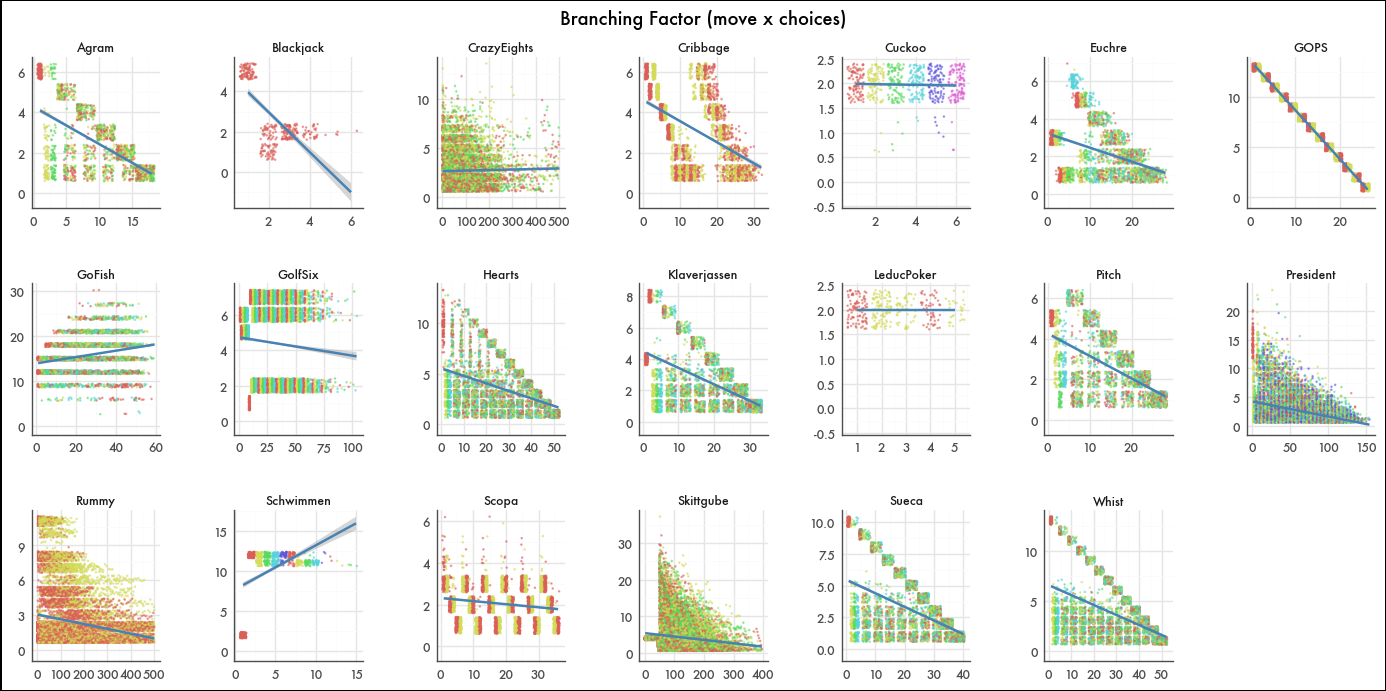

In [932]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("P")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap("game", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("Choices.png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 15 x 15 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Choices.png


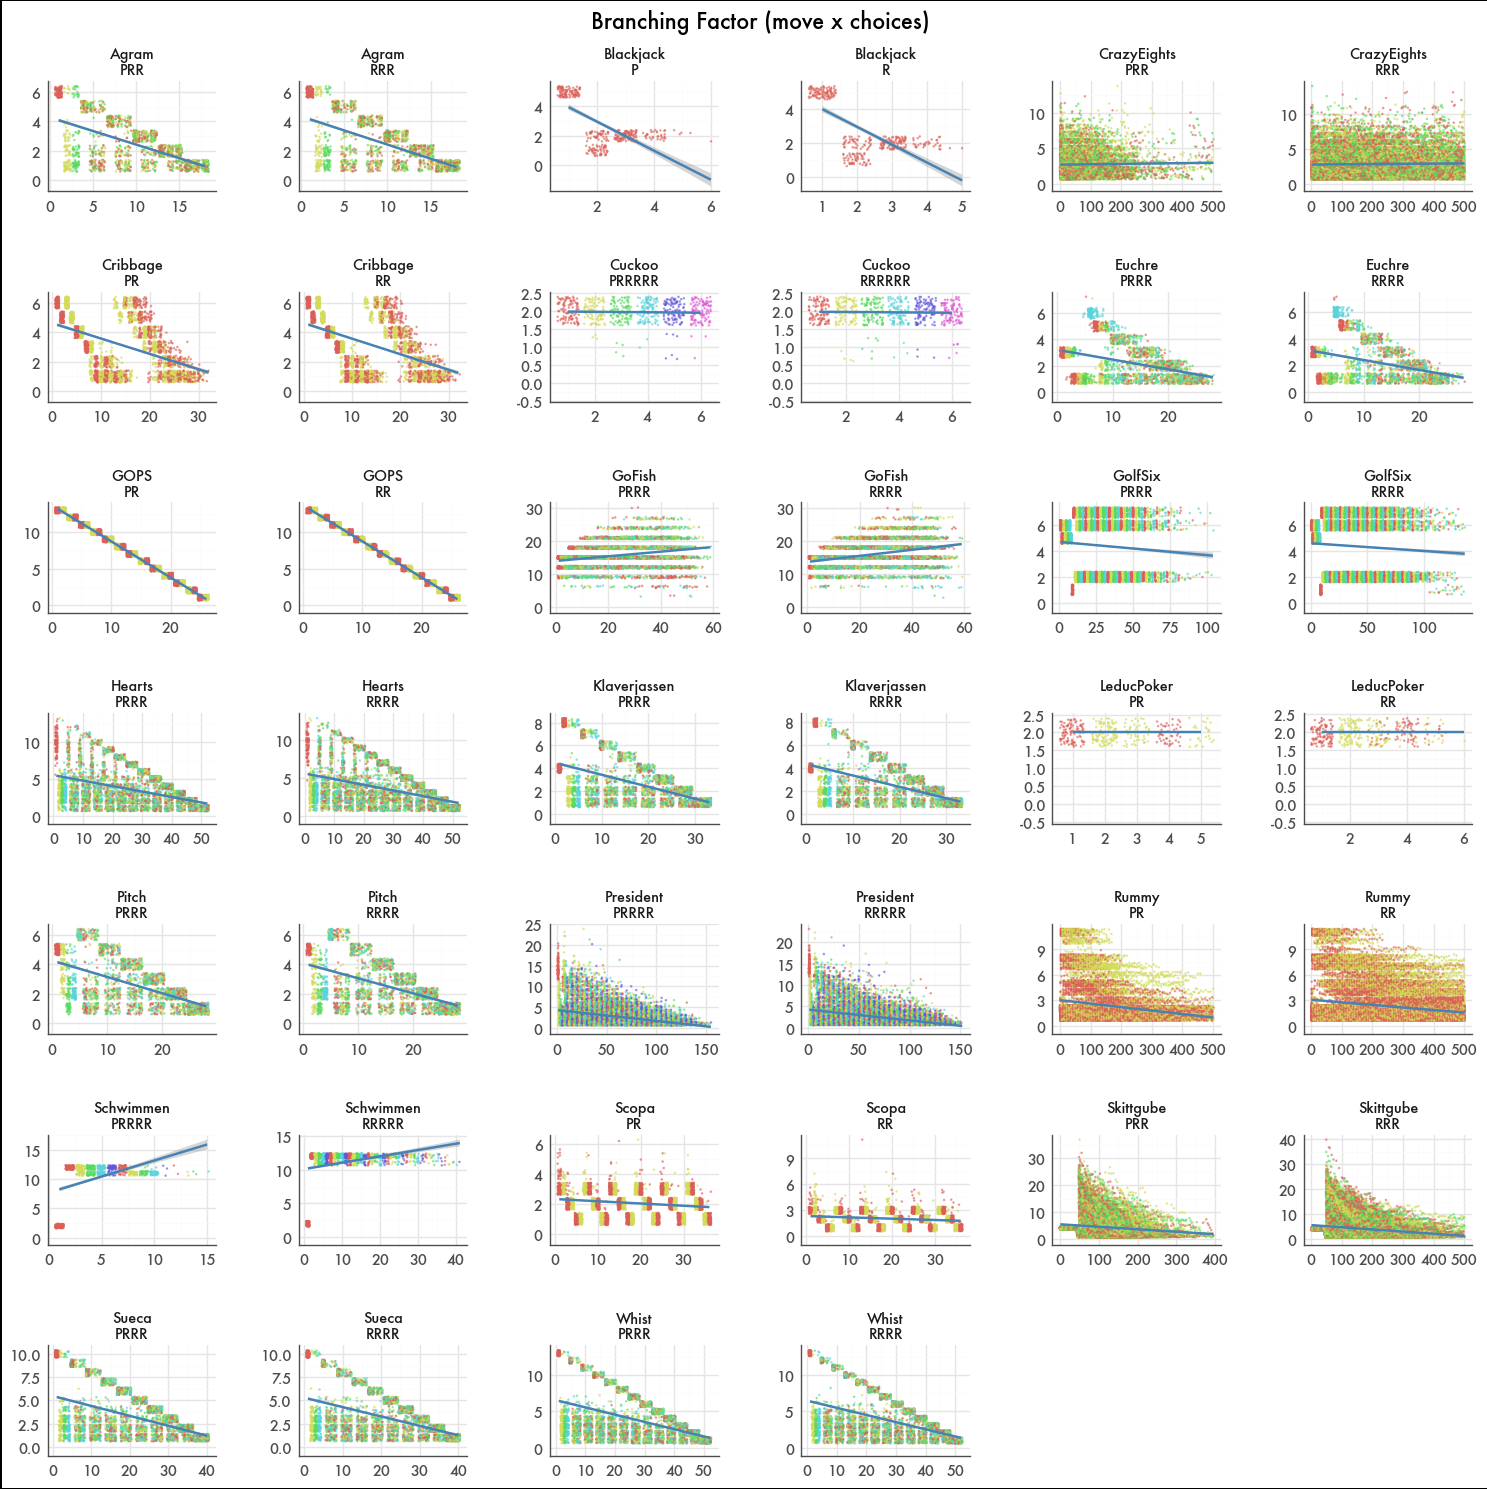

In [933]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe, aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap(["game", "ai"], scales = "free", ncol = 6)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(15, 15))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("Choices.png")
cplot.show()

# Game Length

We can calculate the average game length, by finding the max value for the move column on each run, then averaging

In [934]:
choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()

,game,run,move
0,Agram,50.5,18.00
1,Blackjack,50.5,3.34
2,CrazyEights,50.5,265.29
3,Cribbage,50.5,28.15
4,Cuckoo,50.5,6.00
5,Euchre,50.5,24.53
6,GOPS,50.5,26.00
7,GoFish,50.5,49.13
8,GolfSix,50.5,70.86
9,Hearts,50.5,52.00


In [935]:
lengthf = choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()[['game', 'move']]
gameframe = gameframe.merge(lengthf, on='game', how='left')

In [936]:
gameframe

,game,name,player,convergence,move
0,Agram,Agram,3,0.595360,18.00
1,Blackjack,Blackjack,1,1.139899,3.34
2,CrazyEights,Crazy Eights,3,0.504041,265.29
3,Cribbage,Cribbage,2,0.553263,28.15
4,Cuckoo,Cuckoo,6,0.502742,6.00
5,Euchre,Euchre,4,0.537744,24.53
6,GoFish,Go Fish,4,0.447760,49.13
7,GolfSix,Golf-6,4,0.505097,70.86
8,GOPS,Goofspiel,2,0.748889,26.00
9,Hearts,Hearts,4,0.537803,52.00


In [937]:
lengthf.dtypes

game     object
move    float64
dtype: object

# Fairness

For random games, we want to look at the distribution of scores across the players.

In [938]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["ai"] = "Random"
    if first:
        resultsframe = gf
        first = False
    else:
        resultsframe = pd.concat([resultsframe, gf])
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["ai"] = "PIMC"
    resultsframe = pd.concat([resultsframe, gf])

resultsframe["player"] = resultsframe["player"].astype(str)
resultsframe["rank"] = resultsframe["rank"].astype(str)
resultsframe

,game,numPlayers,ai,run,player,score,rank,time
0,Agram,3,Random,1,1,0.0,2,33
1,Agram,3,Random,1,2,1.0,1,33
2,Agram,3,Random,1,3,0.0,2,33
3,Agram,3,Random,2,1,0.0,2,10
4,Agram,3,Random,2,2,0.0,2,10
...,...,...,...,...,...,...,...,...
395,Whist,4,PIMC,99,4,1.0,1,2742
396,Whist,4,PIMC,100,1,1.0,1,2985
397,Whist,4,PIMC,100,2,0.0,3,2985
398,Whist,4,PIMC,100,3,1.0,1,2985


In [939]:
rf2 = resultsframe.groupby(['game', 'player', 'rank', 'ai'], as_index=False).count()

In [940]:
rf2

,game,player,rank,ai,numPlayers,run,score,time
0,Agram,1,1,PIMC,58,58,58,58
1,Agram,1,1,Random,32,32,32,32
2,Agram,1,2,PIMC,42,42,42,42
3,Agram,1,2,Random,68,68,68,68
4,Agram,2,1,PIMC,22,22,22,22
...,...,...,...,...,...,...,...,...
409,Whist,3,3,Random,51,51,51,51
410,Whist,4,1,PIMC,46,46,46,46
411,Whist,4,1,Random,51,51,51,51
412,Whist,4,3,PIMC,54,54,54,54


In [941]:
rf3 = rf2[(rf2["player"]=="1") & (rf2["rank"] == "1")]
rf3

,game,player,rank,ai,numPlayers,run,score,time
0,Agram,1,1,PIMC,58,58,58,58
1,Agram,1,1,Random,32,32,32,32
12,Blackjack,1,1,PIMC,100,100,100,100
13,Blackjack,1,1,Random,100,100,100,100
14,CrazyEights,1,1,PIMC,75,75,75,75
15,CrazyEights,1,1,Random,38,38,38,38
32,Cribbage,1,1,PIMC,80,80,80,80
33,Cribbage,1,1,Random,54,54,54,54
40,Cuckoo,1,1,PIMC,25,25,25,25
41,Cuckoo,1,1,Random,18,18,18,18


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 15 x 15 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Ranks.png


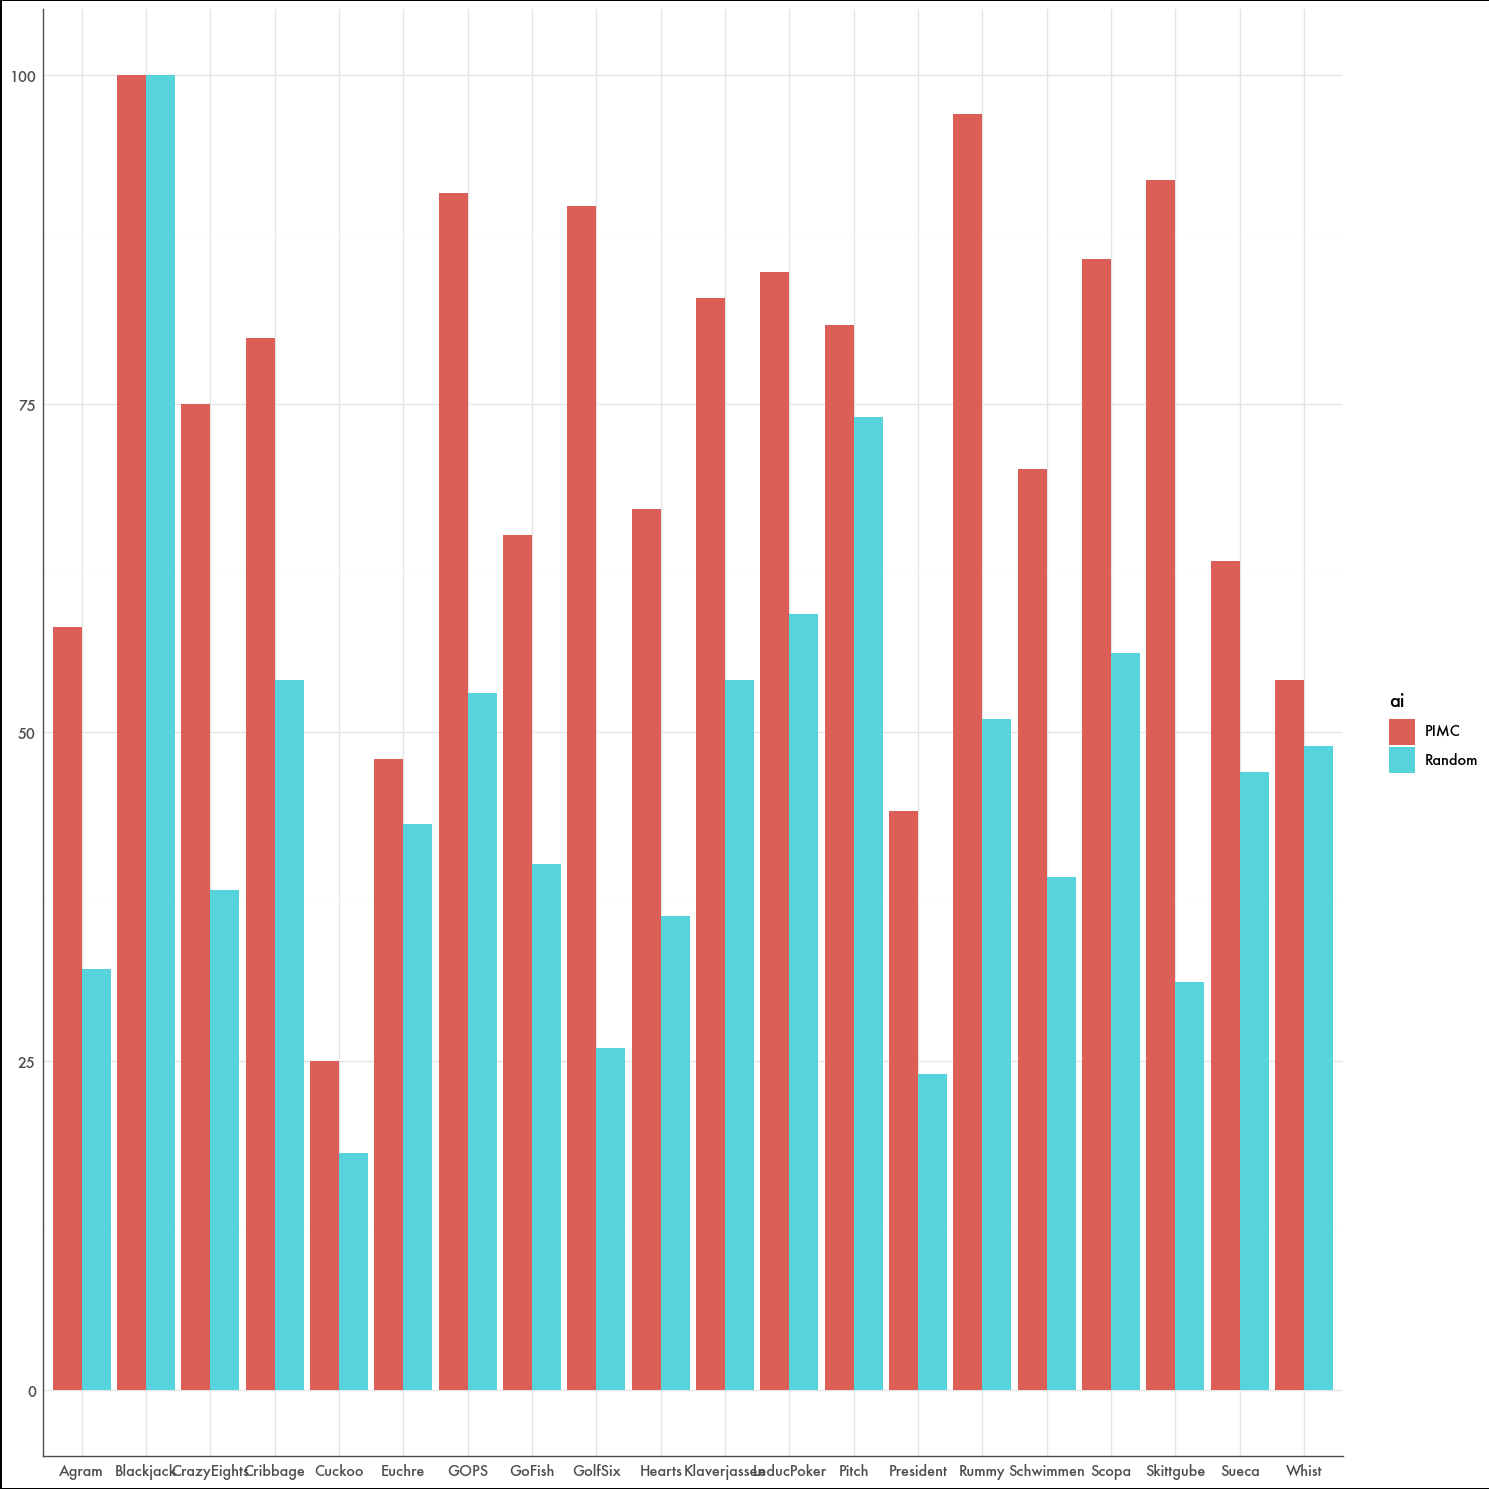

In [942]:
rplot = (ggplot(rf3, aes("game", "run", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(15, 15))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 100)
 + labs(x='player', y='rank')
)
rplot.save("Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Ranks.png


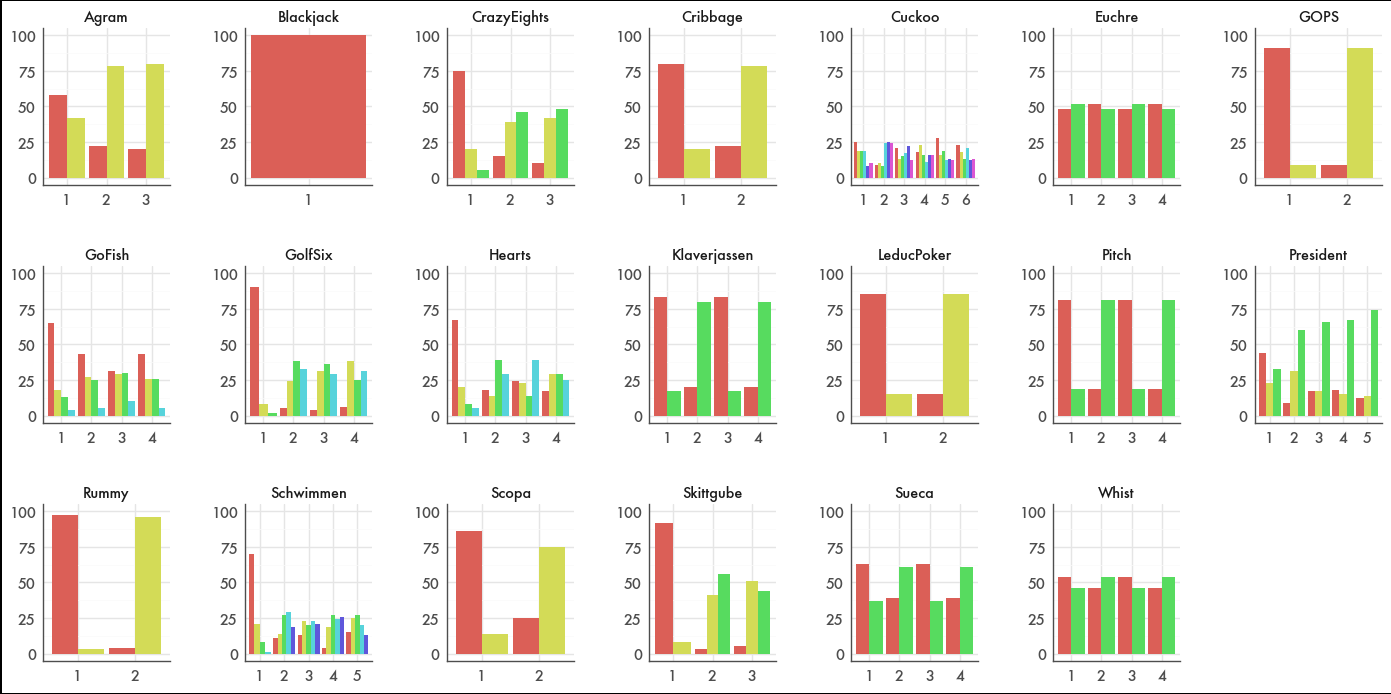

In [943]:
rplot = (ggplot(rf2[rf2["ai"]=="PIMC"], aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 100)
 + labs(x='player', y='rank')
)
rplot.save("Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Scores.png


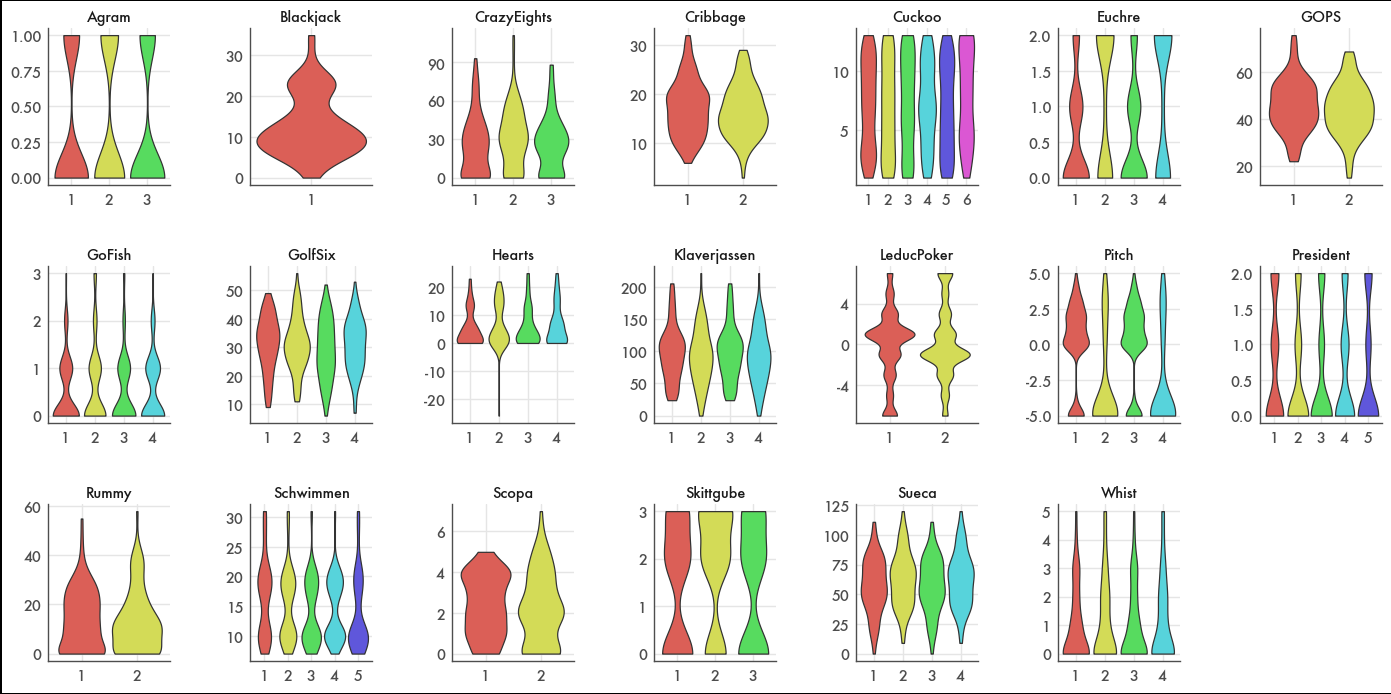

In [944]:
splot = (ggplot(resultsframe[resultsframe["ai"].str.startswith("R")], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
 + scale_y_continuous(minor_breaks=False)
)
splot.save("Scores.png")
splot.show()

In [945]:
rf2 = resultsframe[resultsframe["ai"].str.startswith("P")].groupby(['game', 'player', 'rank'], as_index=False).count()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 15 x 15 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Ranks.png


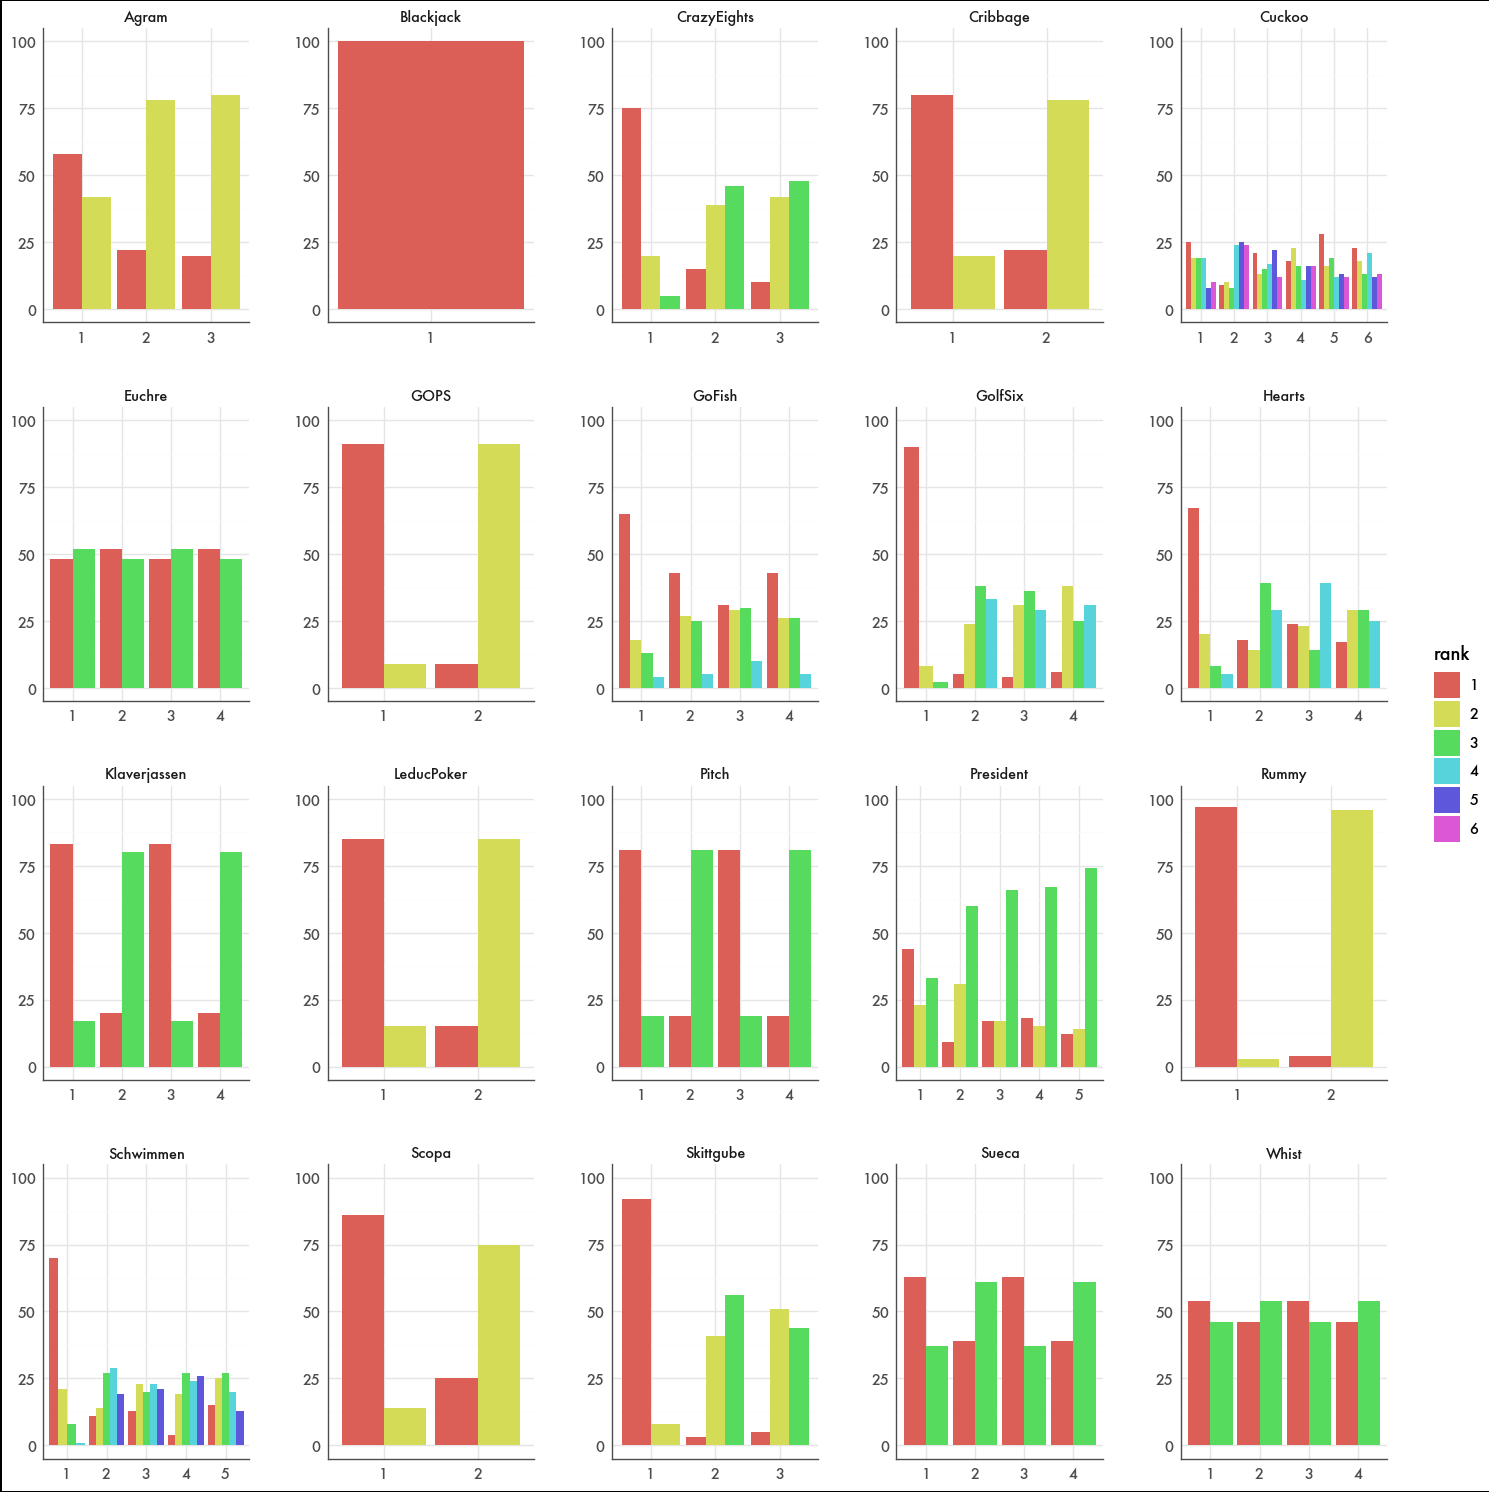

In [946]:
rplot = (ggplot(rf2, aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(15, 15))
 + ylim(0, 100)
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
)
rplot.save("Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 15 x 15 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Scores.png


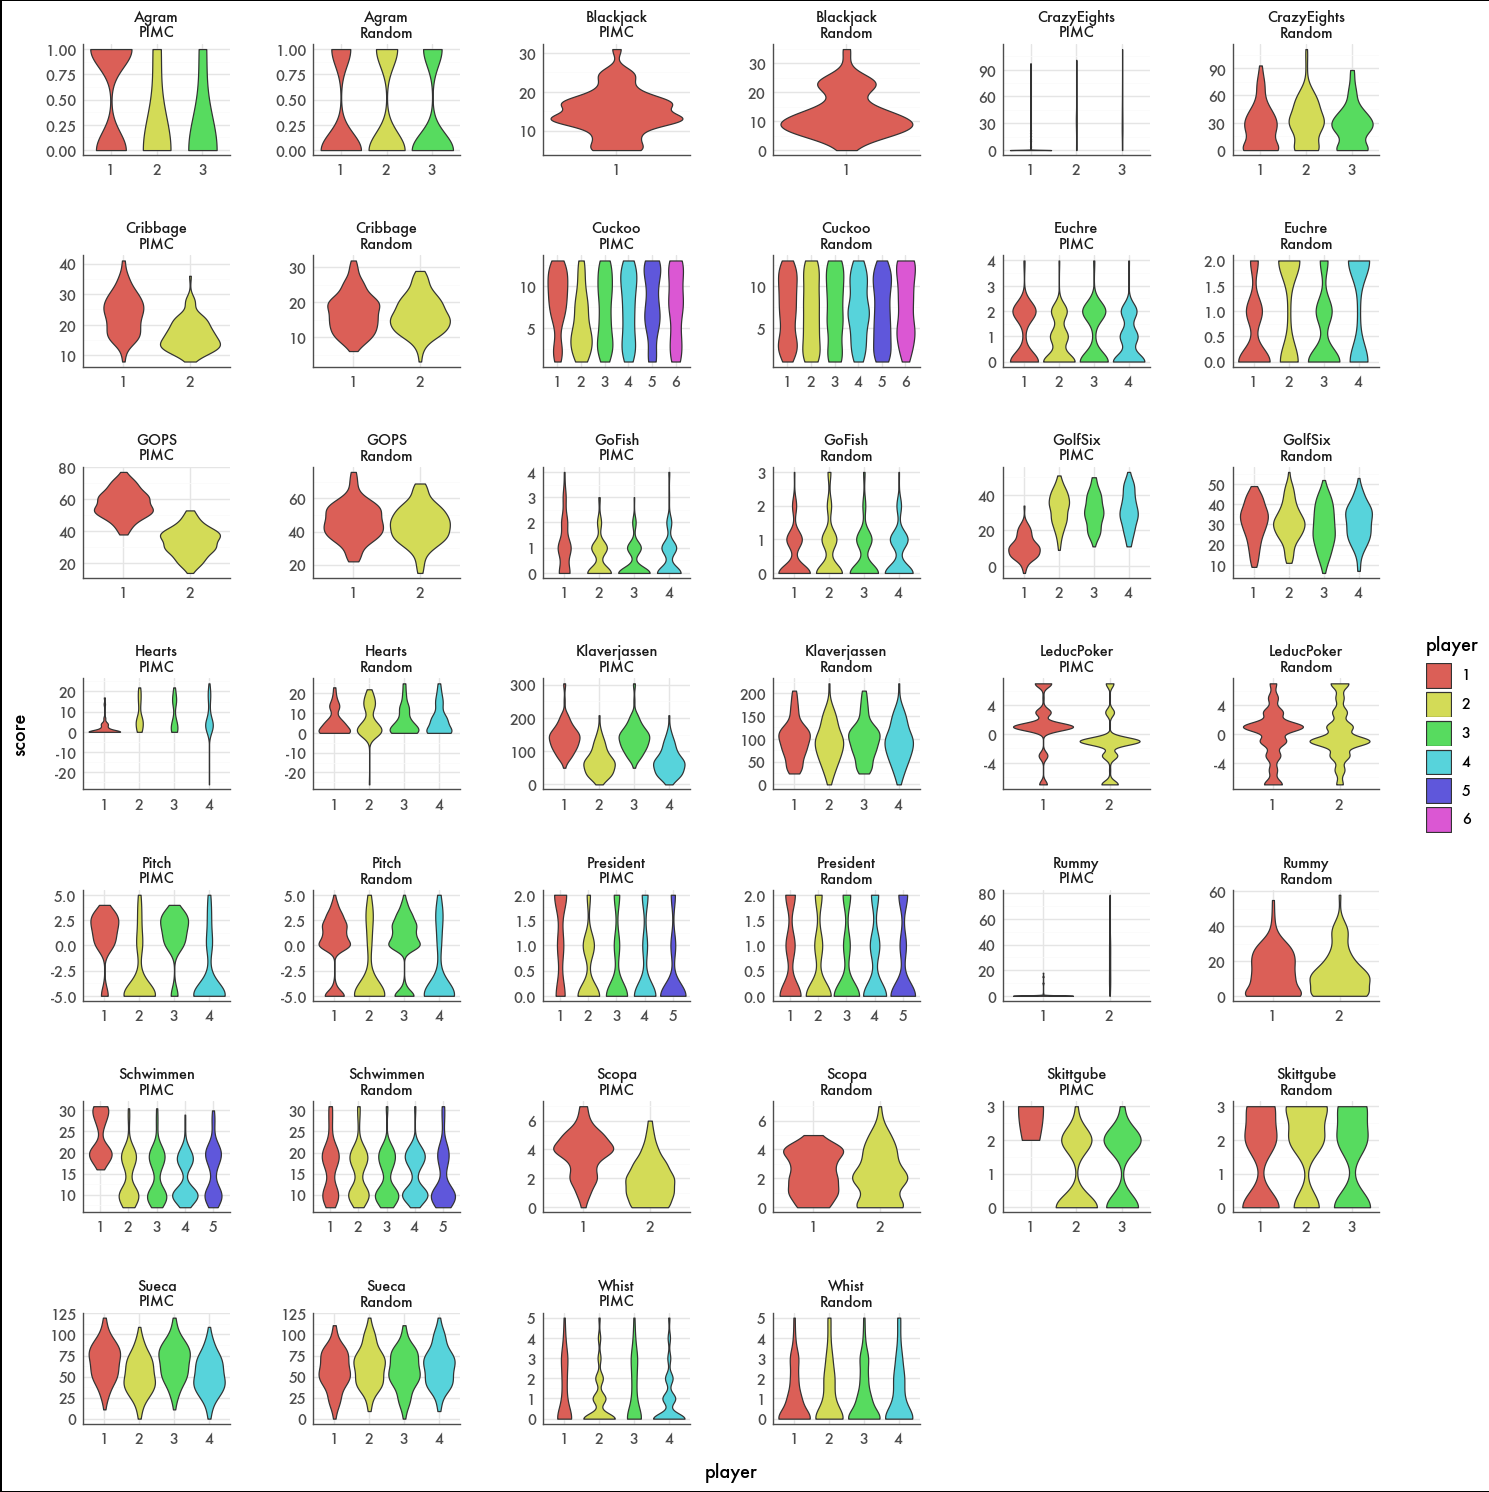

In [947]:
splot = (ggplot(resultsframe, aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap(["game", "ai"], scales = "free", ncol = 6)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(15, 15))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("Scores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Scores.png


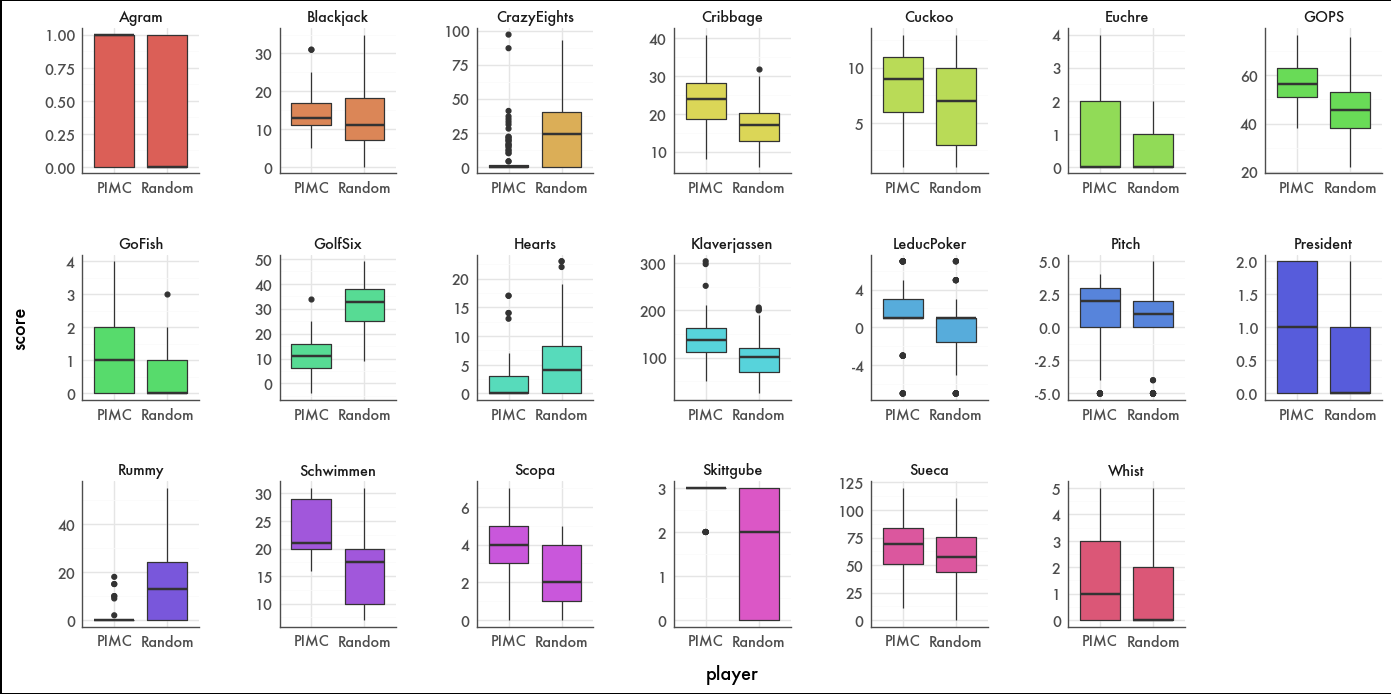

In [948]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="game"))
 + geom_boxplot()
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("Scores.png")
splot.show()

# Spread

In [949]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/spread.csv")
    gf["game"] = row["game"]
    if row["game"] == "Schwimmen":
        gf["spread"] = gf["spread"] / 2.0
    if first:
        spreadframe = gf
        first = False
    else:
        spreadframe = pd.concat([spreadframe, gf])
spreadframe["player"] = spreadframe["player"].astype(str)
spreadframe["run"] = spreadframe["run"].astype(str)


In [950]:
spreadframe

,game,numPlayers,ai,run,pmove,player,spread
0,Agram,3,PRR,1,1,0,0.18
1,Agram,3,PRR,1,2,0,0.01
2,Agram,3,PRR,1,3,0,0.36
3,Agram,3,PRR,1,4,0,0.19
4,Agram,3,PRR,1,5,0,0.06
...,...,...,...,...,...,...,...
1295,Whist,4,PRRR,100,9,0,0.00
1296,Whist,4,PRRR,100,10,0,0.09
1297,Whist,4,PRRR,100,11,0,0.00
1298,Whist,4,PRRR,100,12,0,0.17


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


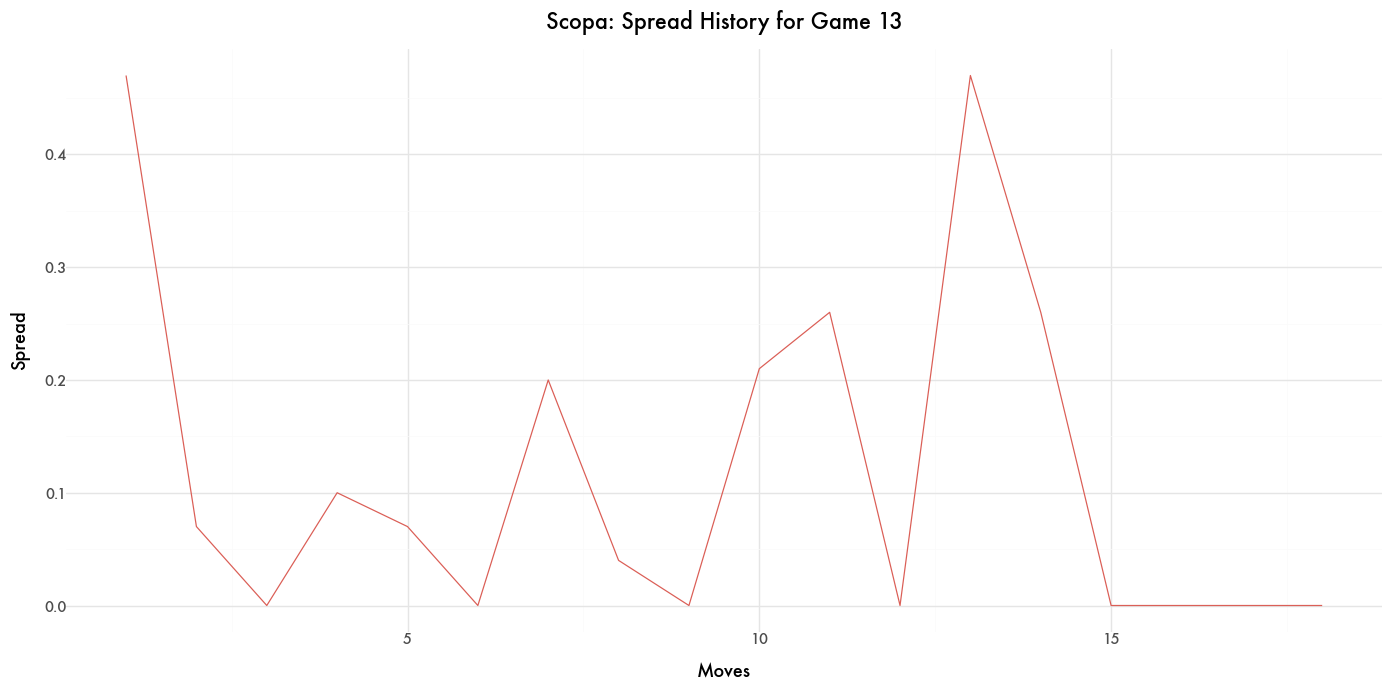

In [953]:
game = "Scopa"
iter = "13"
splot = (ggplot(spreadframe[(spreadframe["run"] == iter) & (spreadframe["game"] == game)], 
       aes(x="pmove", y="spread", color="player"))
 + geom_line()
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History for Game " + str(iter))
)
splot.save("Spread.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


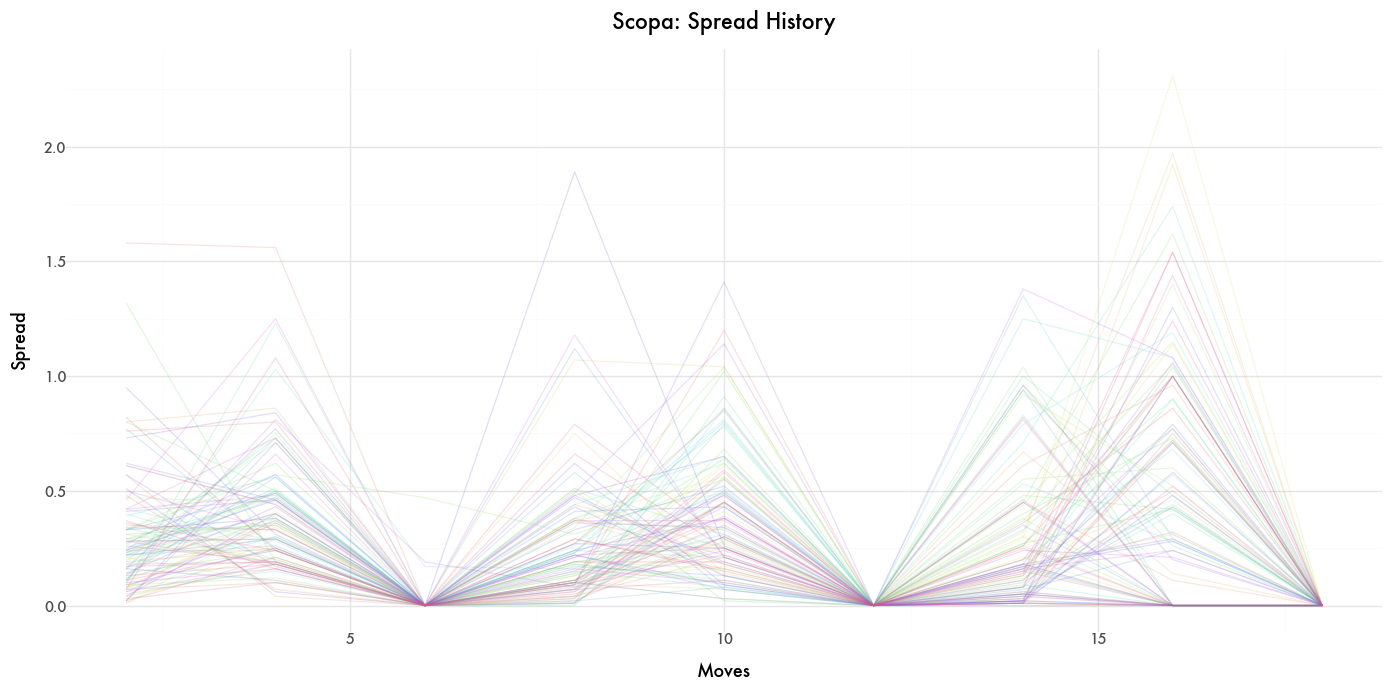

In [954]:
splot = (ggplot(spreadframe[(spreadframe["game"] == game) & (spreadframe["pmove"]%2 == 0)], 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History")
)
splot.save("Spread.png")
splot.show()

In [955]:
spreadframe[(spreadframe["game"] == game)]

,game,numPlayers,ai,run,pmove,player,spread
0,Scopa,2,PR,1,1,0,0.30
1,Scopa,2,PR,1,2,0,0.28
2,Scopa,2,PR,1,3,0,0.00
3,Scopa,2,PR,1,4,0,0.18
4,Scopa,2,PR,1,5,0,0.20
...,...,...,...,...,...,...,...
1795,Scopa,2,PR,100,14,0,0.01
1796,Scopa,2,PR,100,15,0,0.00
1797,Scopa,2,PR,100,16,0,0.00
1798,Scopa,2,PR,100,17,0,0.00


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:113: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:113: PlotnineWarning: geom_path: Each group consist of only one observation. Do you need to adjust the group aesthetic?


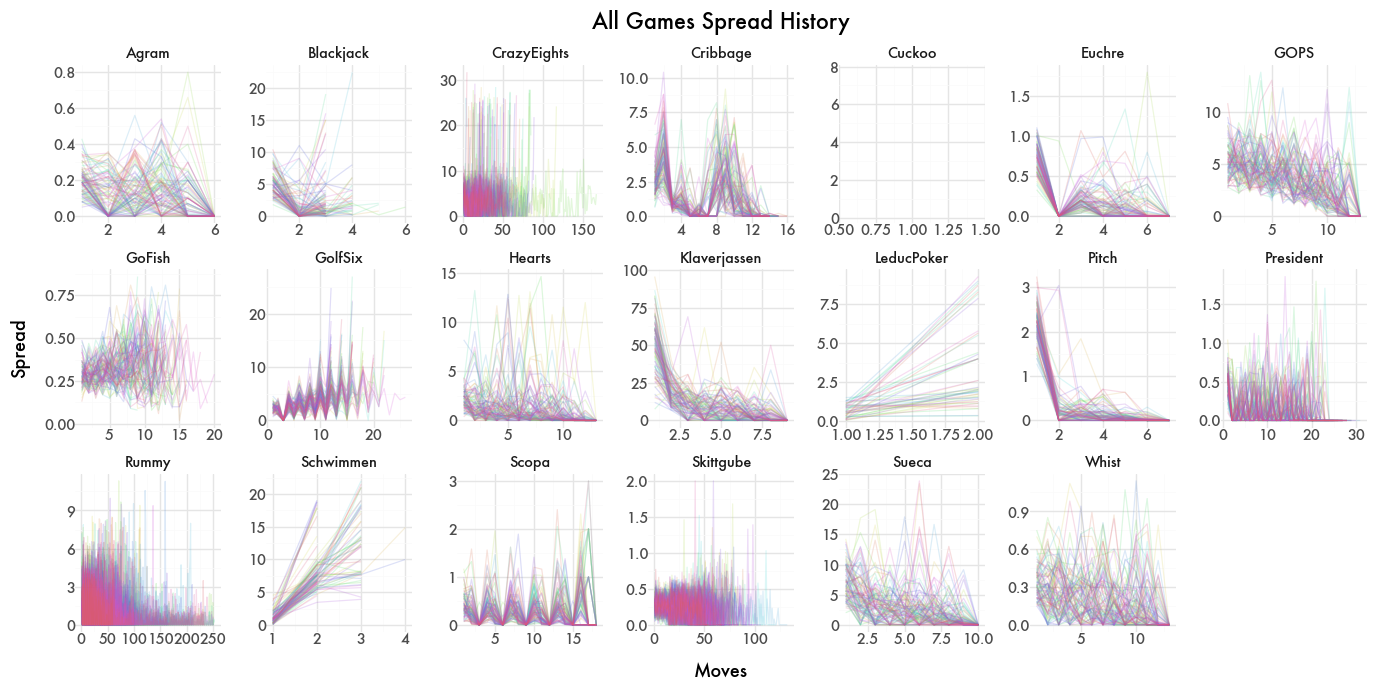

In [956]:
splot = (ggplot(spreadframe, 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title="All Games Spread History")
)
splot.save("Spread.png")
splot.show()

# Lead History 

First, we create the Dataframe for storing all of the game statistics for the lead histories, then we can use this to project multiple graphs.

The **Security** and **Drama** Heuristics are calculated as part of this process.

In [958]:
first = True
for index, row in gameframe.iterrows():
    #gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/lead.csv")
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "PPPPPP" + "/lead.csv")
    gf["game"] = row["game"]
    if first:
        leadframe = gf
        first = False
    else:
        leadframe = pd.concat([leadframe, gf])


In [959]:
leadframe["player"] = leadframe["player"].astype(str)
leadframe["run"] = leadframe["run"].astype(str)
leadframe["rank"] = leadframe["rank"].astype(str)
leadframe[leadframe["game"] == "Blackjack"]

,game,numPlayers,ai,run,move,recorder,player,score,rank,rankestimate
0,Blackjack,1,PPPPPP,1,1,1,1,13.5,0,NaN
1,Blackjack,1,PPPPPP,1,2,1,1,13.8,0,NaN
2,Blackjack,1,PPPPPP,1,3,1,1,15.0,0,NaN
3,Blackjack,1,PPPPPP,1,4,1,1,13.0,0,NaN
4,Blackjack,1,PPPPPP,2,1,1,1,14.9,0,NaN
...,...,...,...,...,...,...,...,...,...,...
425,Blackjack,1,PPPPPP,99,6,1,1,21.0,0,NaN
426,Blackjack,1,PPPPPP,100,1,1,1,14.8,0,NaN
427,Blackjack,1,PPPPPP,100,2,1,1,13.4,0,NaN
428,Blackjack,1,PPPPPP,100,3,1,1,13.4,0,NaN


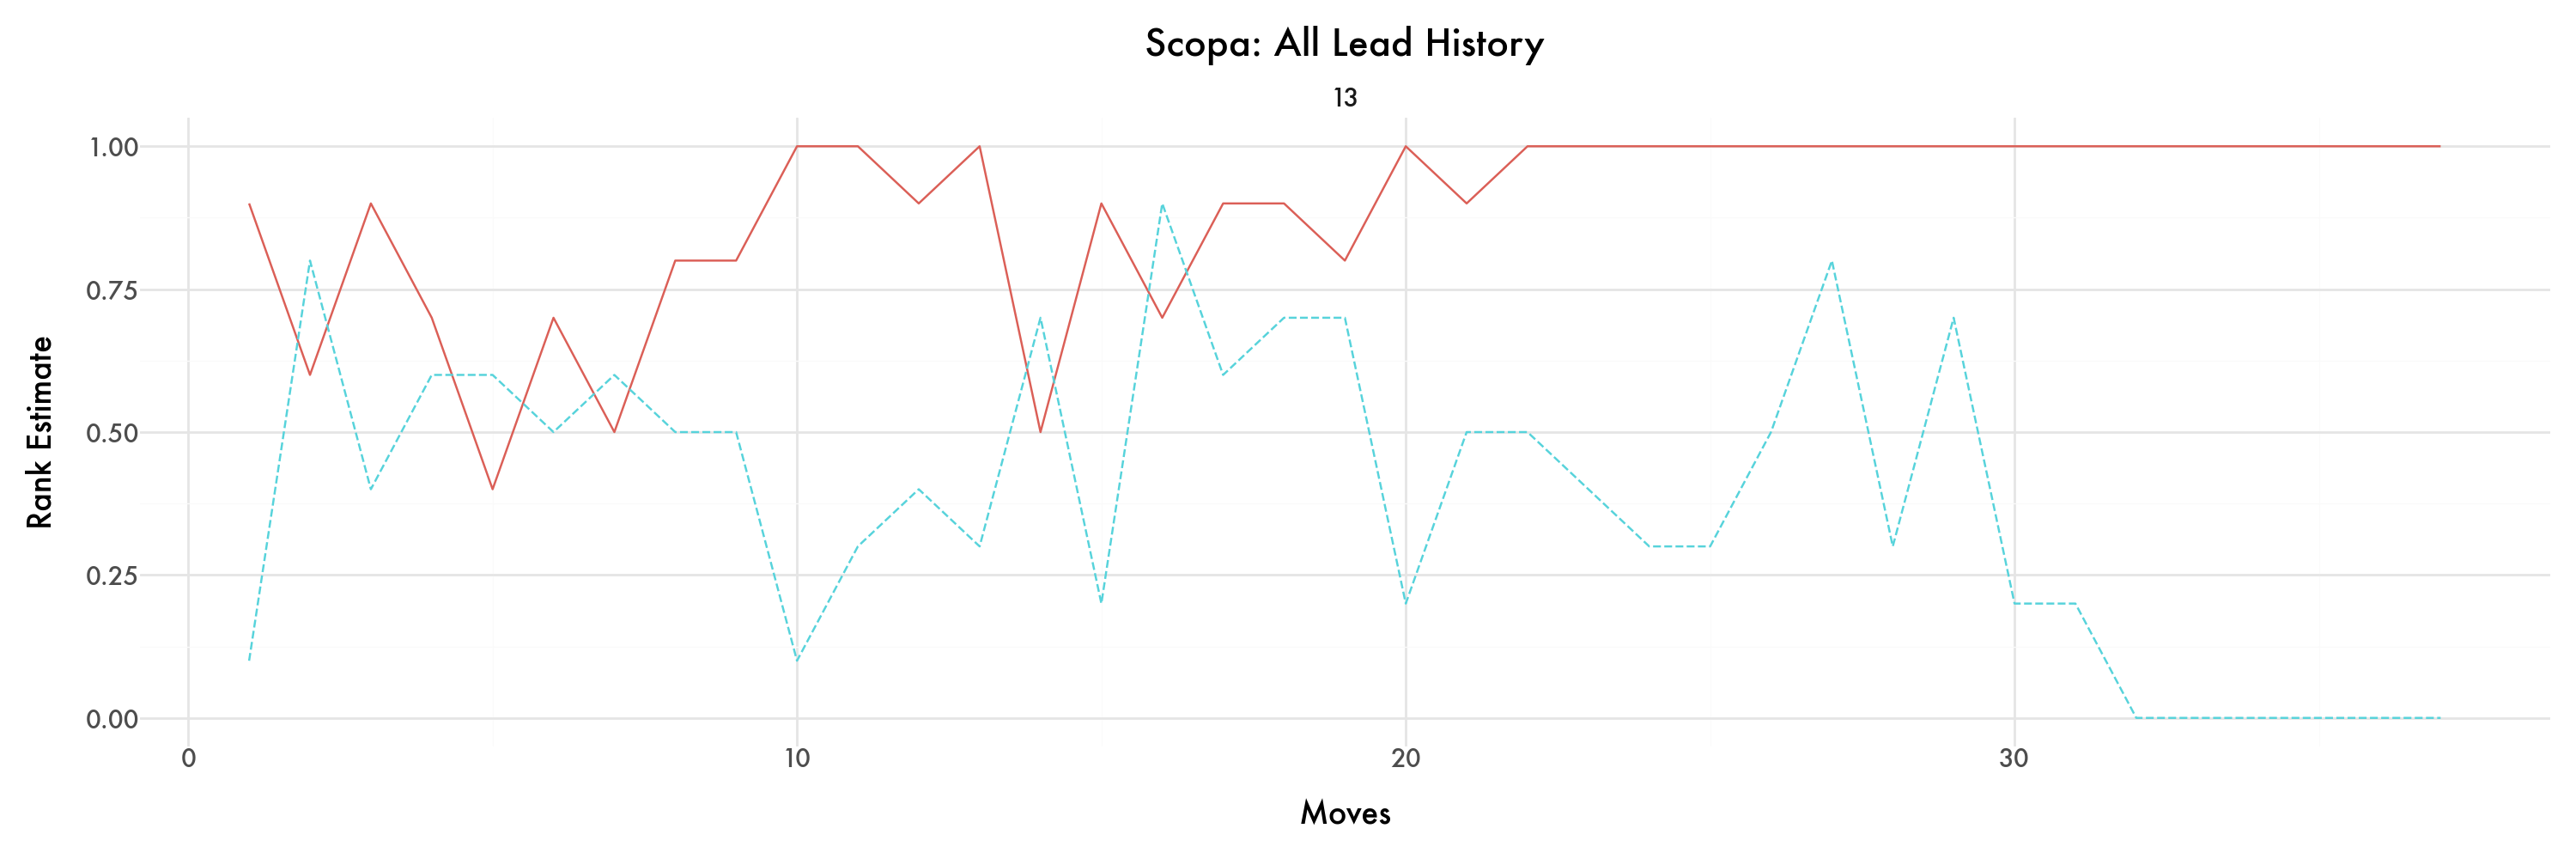

In [960]:
game = "Scopa"
(ggplot(leadframe[(leadframe["game"] == game) & (leadframe["run"]== iter)], 
       aes(x="move", y="rankestimate", color="player"))
 + geom_line(aes(linetype="rank"))
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(15, 5))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
)

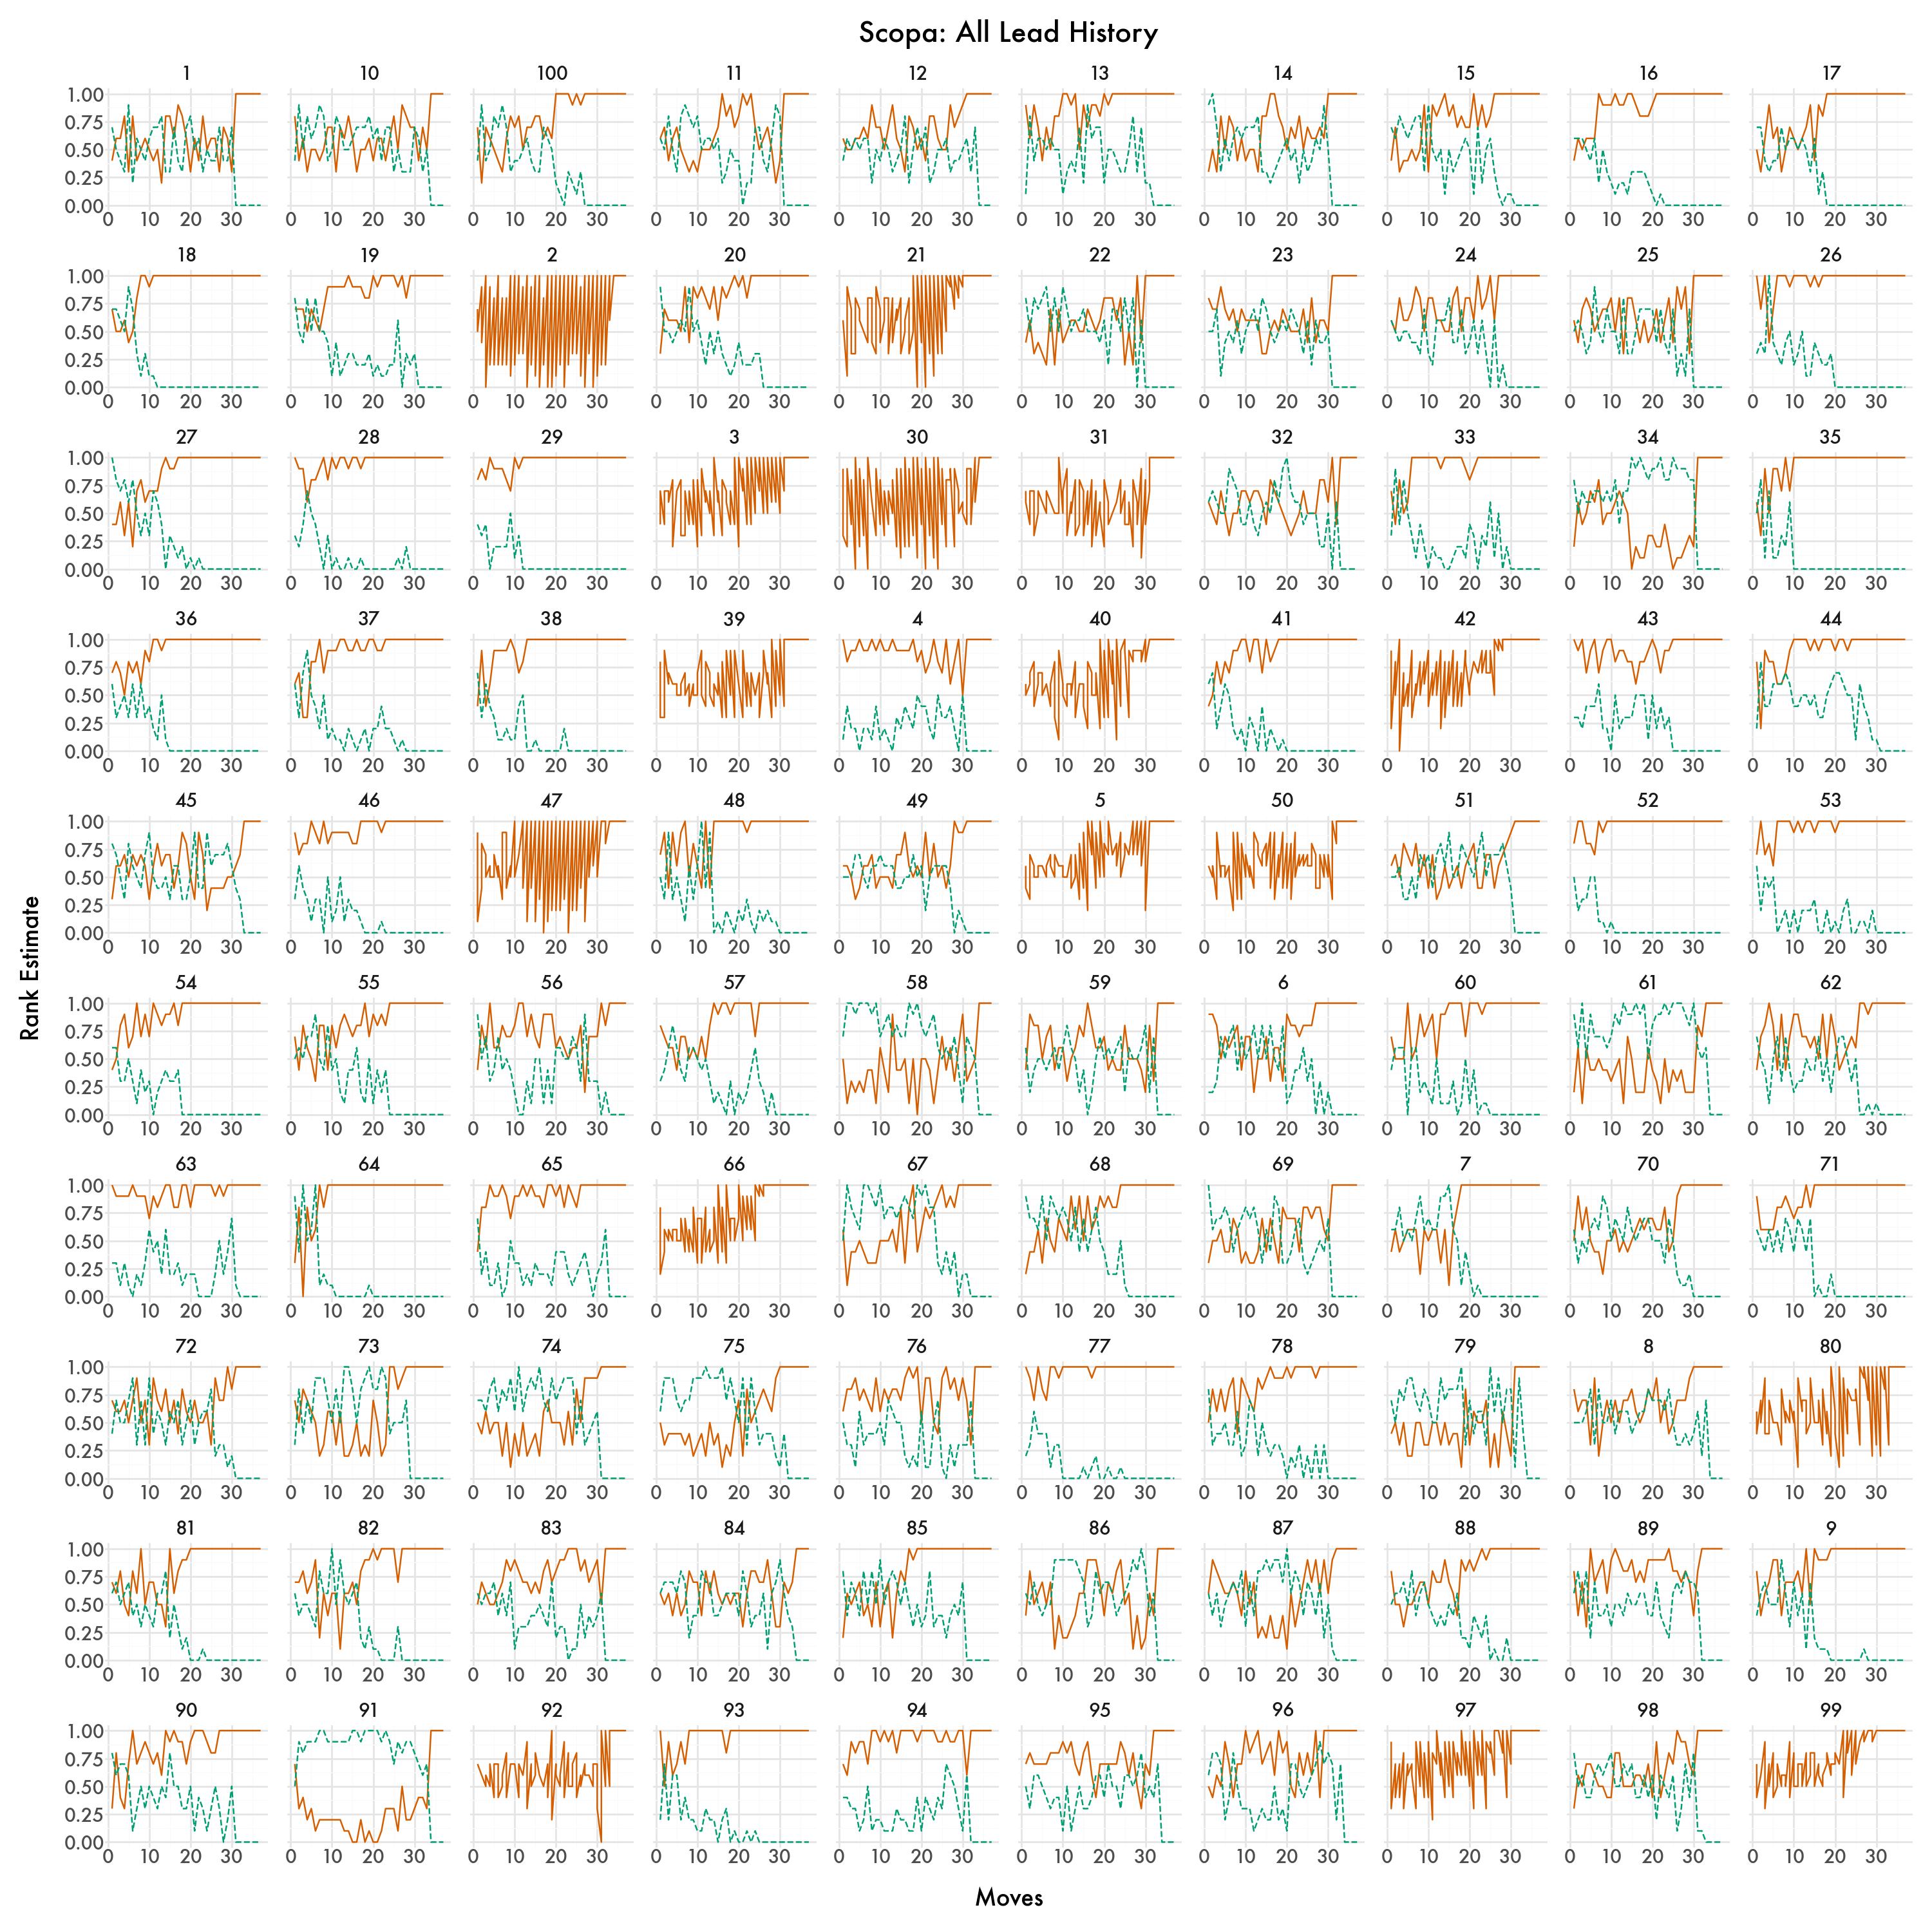

In [961]:
(ggplot(leadframe[(leadframe["game"] == game)], 
       aes(x="move", y="rankestimate", color="rank"))
 + geom_line(aes(linetype="rank"))
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(15, 15))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
 + scale_colour_manual(values=cbbPalette)
)

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 4 rows containing missing values.


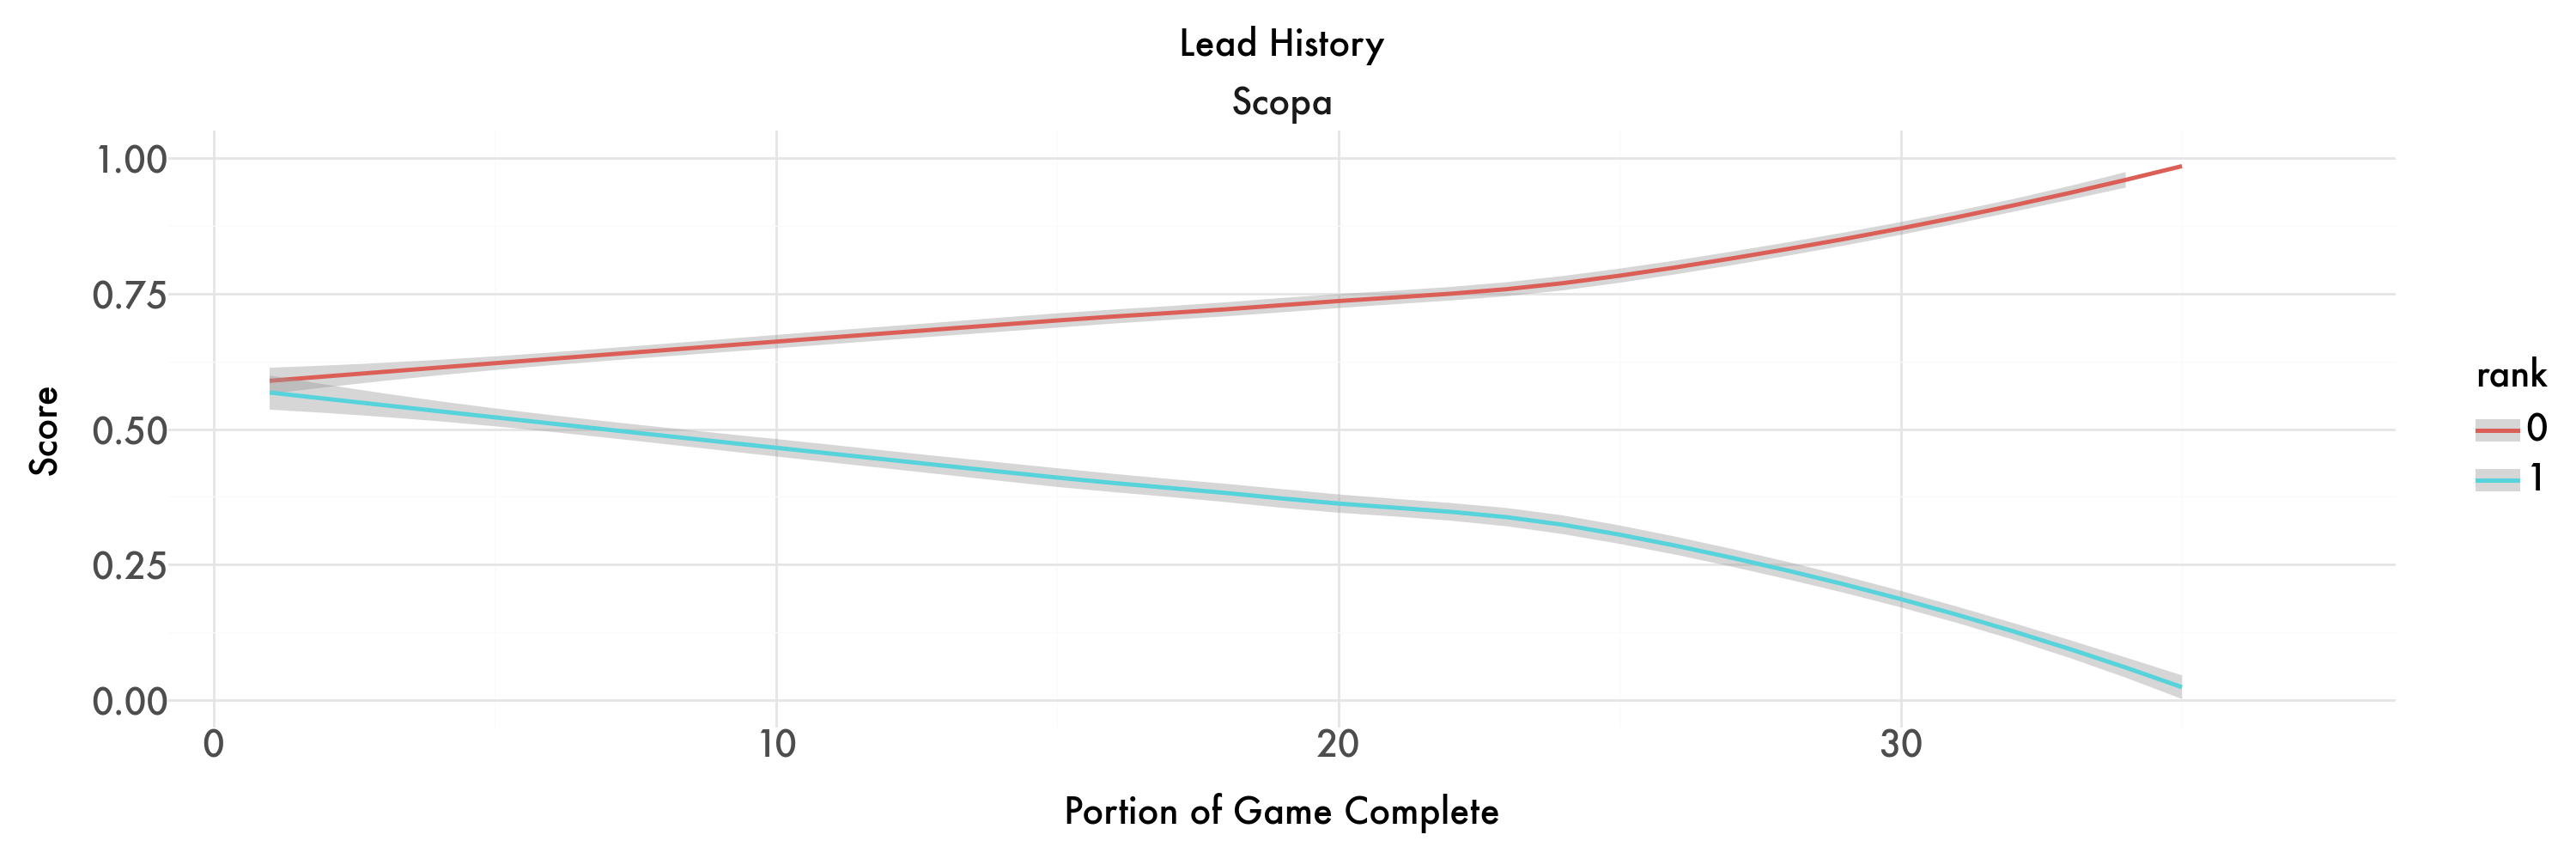

In [962]:
(ggplot(leadframe[(leadframe["game"] == game)], 
       aes(x="move", y="rankestimate", color="rank"))
 + geom_smooth(method="loess")
 + ylim(0, 1)
 + facet_wrap("game")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(15, 5), text=element_text(size=15))
 + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Lead.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 66 rows containing missing values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 66 rows containing missing values.


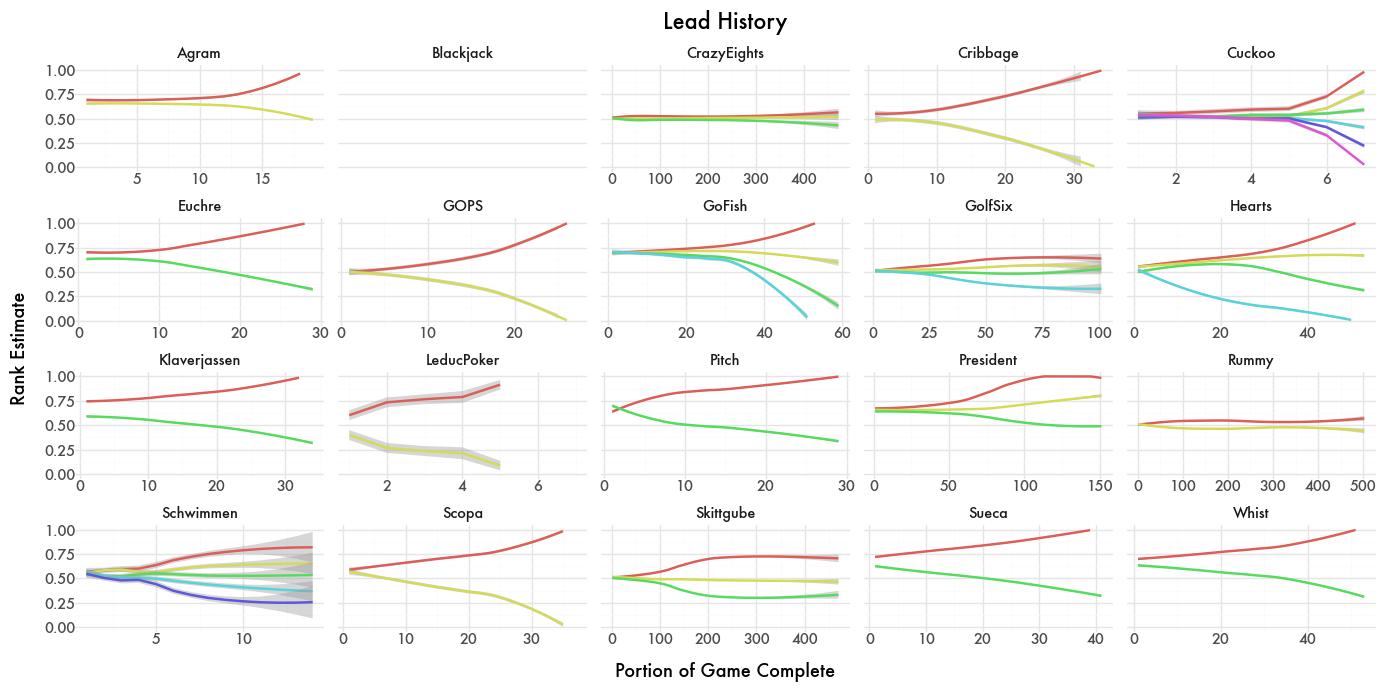

In [966]:
lplot = (ggplot(leadframe[(leadframe["game"] == "LeducPoker") | (leadframe["game"] == "Rummy") | (leadframe["game"] == "President") | (leadframe["game"] == "GoFish") | (leadframe["game"] == "CrazyEights") | (leadframe["game"] == "Agram") | (leadframe["game"] == "Skittgube") | (leadframe["game"] == "GolfSix")| (leadframe["game"] == "Schwimmen")| (leadframe["game"] == "Whist")| (leadframe["game"] == "Klaverjassen")| (leadframe["game"] == "Euchre")| (leadframe["game"] == "Pitch")| (leadframe["game"] == "Cuckoo")| (leadframe["game"] == "GOPS")| (leadframe["game"] == "Scopa")| (leadframe["game"] == "Hearts") | (leadframe["game"] == "Blackjack")| (leadframe["game"] == "Cribbage")| (leadframe["game"] == "Sueca")], 
       aes(x="move", y="rankestimate", color="rank"))
 + geom_smooth(method="loess")
 + ylim(0, 1)
 + facet_wrap("game", scales="free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Portion of Game Complete', y='Rank Estimate', title="Lead History")
)
lplot.save("Lead.png")
lplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Lead.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 5 rows containing missing values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 5 rows containing missing values.


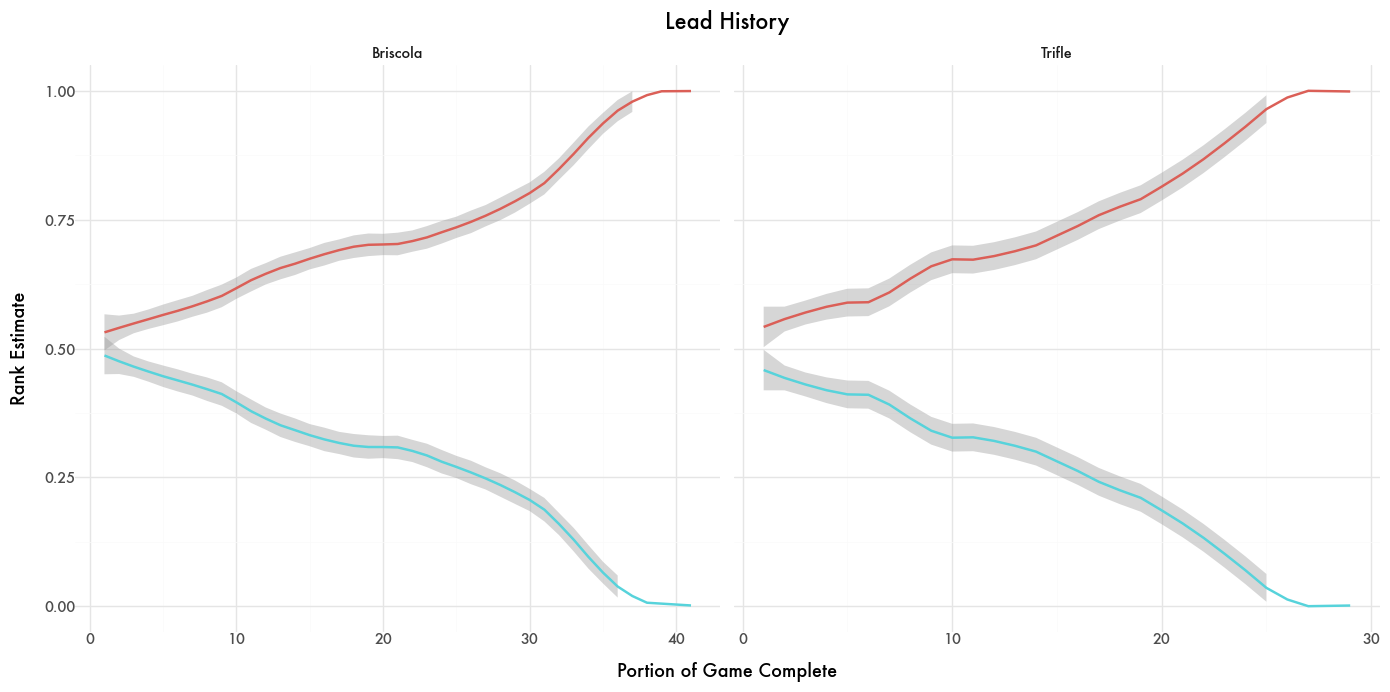

In [915]:
lplot = (ggplot(leadframe, aes(x="move", y="rankestimate", color="rank"))
 + geom_smooth(method="loess", span=0.3)
 + ylim(0, 1)
 + facet_wrap("game", scales="free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Portion of Game Complete', y='Rank Estimate', title="Lead History")
)
lplot.save("Lead.png")
lplot.show()